In [1]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

## Funcions Adicionals

In [ ]:
class Rosenbrock:
    def __init__(self):
        self.name = "Rosenbrock"
        self.minima= (1, 1)
        self.limits = [(-2, 2), (-1, 3)]

    def evaluate(self, x, y):
        return (20 + (x**2 - 10*np.cos(2*np.pi*x)) + (y**2 - 10*np.cos(2*np.pi*y)))

    #def evaluate_with_error(self, x, y, err: float=0.0):
    #    # l'error es rep com a float. Es a dir, un 20% d'error correspont a err=0.2
    #    error_random = XXX(1+err, 1-err)
    #    return error_random*((1 - x)**2 + 100*(y - (x**2))**2)

class Rastrigin: 
    def __init__(self):
        self.name = "Rastrigin"
        self.minima = [(0, 0)] # Mínimo global en (0, 0)
        self.limits = (-5.12, 5.12) # Límites típicos para la función Rastrigin
    
    def evaluate(self, x, y):
        return (20 + (x**2 - 10*np.cos(2*np.pi*x)) + (y**2 - 10*np.cos(2*np.pi*y)))
    
class Himmelblau:
    def __init__(self):
        self.name   = "Himmelblau"
        self.minima = [(3, 2), (-2.805, 3.131), (-3.779, -3.283), (3.584, -1.848)]
        self.limits = [(-6, 6), (-6, 6)]

    def evaluate(self, x, y):
        return (x**2 + y - 11)**2 + (x + y**2 - 7)**2
    
class Beale:
    def __init__(self):
        self.name   = "Beale"
        self.minima = [(3, 0.5)]
        self.limits = [(-4, 4), (-4, 4)]

    def evaluate(self, x, y):
        return (1.5 - x + x*y)**2 + (2.25 - x + x*y**2)**2 + (2.625 - x + x*y**3)**2

In [3]:
def lectura(filepath: str):
    # 1. Cargar datos 
    # Leemos el archivo detectando automáticamente el separador (puede ser coma, punto y coma, tabulación, etc.)
    df = pd.read_csv(filepath, sep=None, engine='python')

    # Limpiamos nombres de columnas (quita espacios invisibles como " X" -> "X")
    df.columns = df.columns.str.strip()
    print(f"Columnas detectadas: {list(df.columns)}")

    # 3. Extraer valores de la columna 2 (X) y de la columna 3(Y) (Usando .iloc es más seguro si las columnas son la 2 y la 3)
    val_x = df.iloc[:, 1] # iloc[:, 1] es la segunda columna donde estan los valores de X
    val_y = df.iloc[:, 2] # iloc[:, 2] es la tercera columna donde estan los valores de Y

    return val_x, val_y, df

In [5]:
def plot_round(val_x, val_y, funcio: function, round: str): #, save_figure: bool = False): 

    ###-PLOT-###
    # 1. Crear el fondo de la función
    x_range = np.linspace(funcio.limits[0][0], funcio.limits[0][1], 400)
    y_range = np.linspace(funcio.limits[1][0], funcio.limits[1][1], 400)
    X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
    Z_mesh = funcio.evaluate(X_mesh, Y_mesh)

    # 2. Dibujar el mapa
    plt.figure(figsize=(10, 7))
    plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=np.logspace(-2, 5, 40), norm=LogNorm(vmin=0.01, vmax=10**5), cmap='viridis', alpha=0.8)
    plt.colorbar(label=f'{funcio.name} value')

    # 3. Dibujar TUS puntos (usando el df que ya tienes en memoria)
    plt.scatter(val_x, val_y, color='red', edgecolors='white', s=80, label='Explored points')

    #afegir les linies de contorn blanques dels punts
    #plt.contour(X_mesh, Y_mesh, Z_mesh, levels=15, colors='white', linewidths=0.5, alpha=0.8)

    # Añadir etiquetas de número de RUN
    #for i, row in df.iterrows():
    #    plt.text(row.iloc[1]+0.1, row.iloc[2]+0.1, str(int(row.iloc[0])), color='white', fontsize=9)

    plt.title(f"Round {round}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()

    return plt


## Main

------------------------------
Procesando archivo: Himmelblau_R0.csv
Guardando Output en Himmelblau_R0_RESULTADO.csv
Guardando Gráfico en Himmelblau_R0_plot.jpg
Round: 0
------------------------------
Columnas detectadas: ['RUN', 'X', 'Y']
   RUN     X        Y        real
0    1  1.02  0.60000  119.186512
1    2  1.08  6.00000  919.502889
2    3 -3.00  1.86000   42.796432
3    4 -6.00 -1.20000  700.073600
4    5 -6.00 -5.23437  598.000655
------------------------------
Procesando archivo: Himmelblau_R1.csv
Guardando Output en Himmelblau_R1_RESULTADO.csv
Guardando Gráfico en Himmelblau_R1_plot.jpg
Round: 1
------------------------------
Columnas detectadas: ['Number', 'X', 'Y', 'R1']
   Number      X      Y        R1        real
0       1 -3.112  1.389  -138.447   66.961644
1       2 -0.423 -4.576   -98.111  419.773029
2       3  0.420 -2.480  -691.826  177.170329
3       4 -3.600 -2.400 -1457.100   23.619200
4       5  5.850 -0.884   -19.032  499.144407
------------------------------


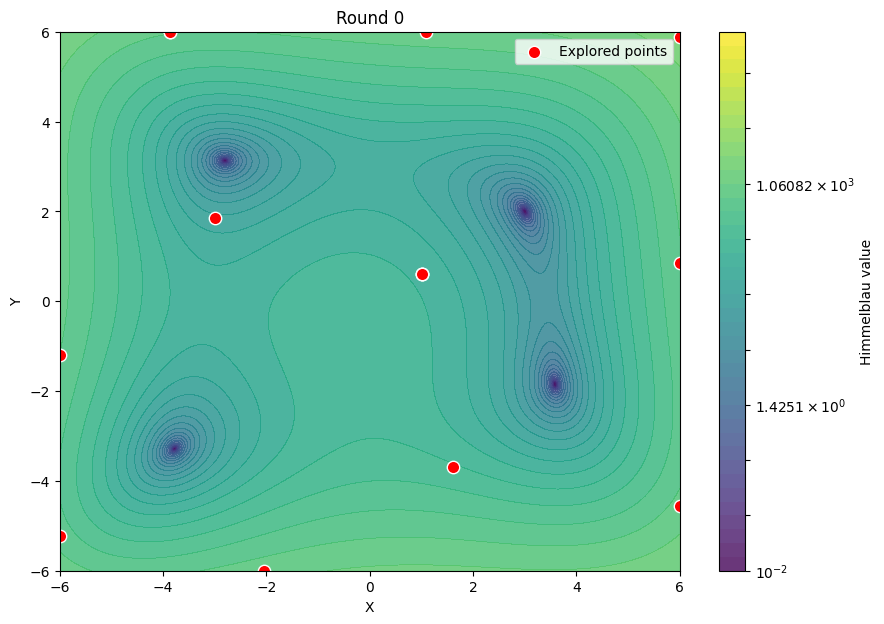

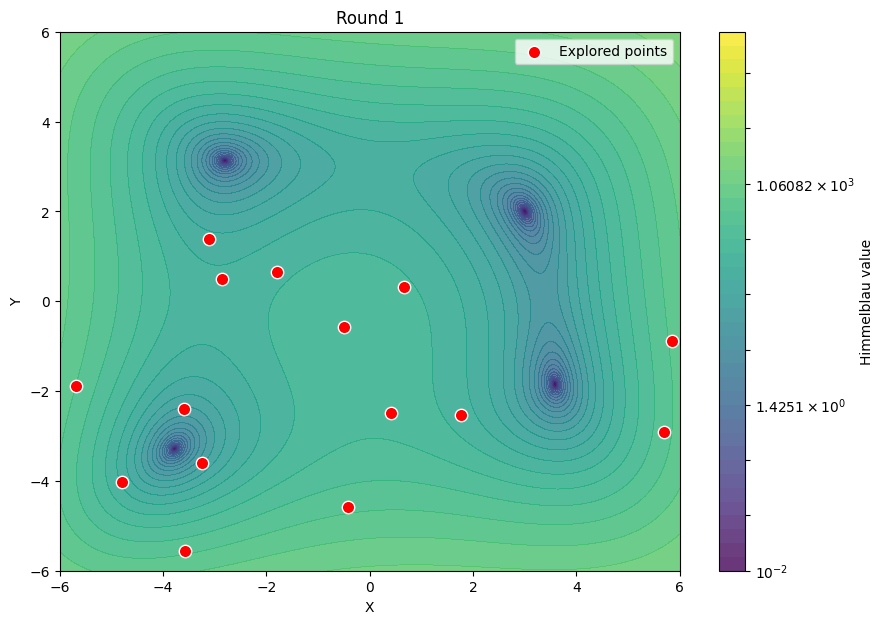

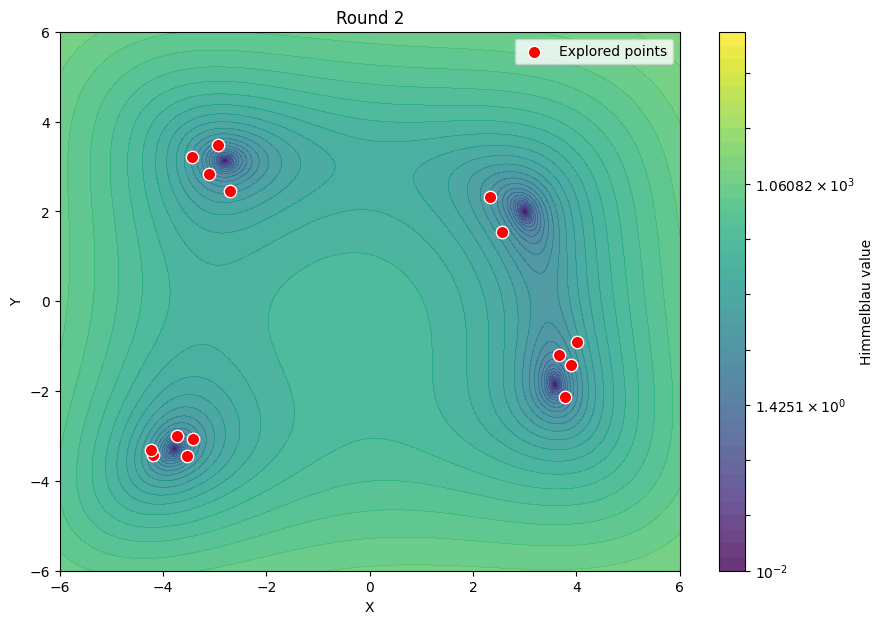

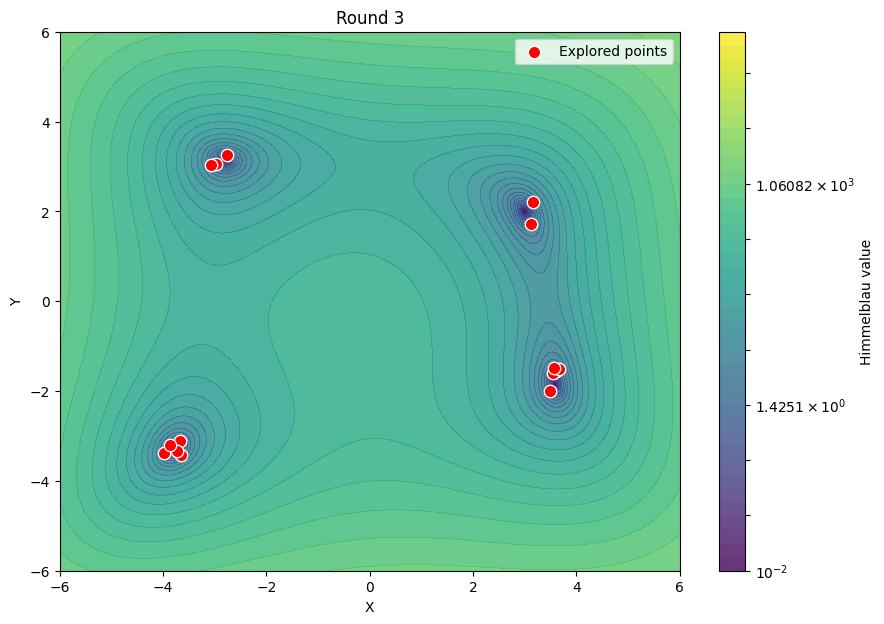

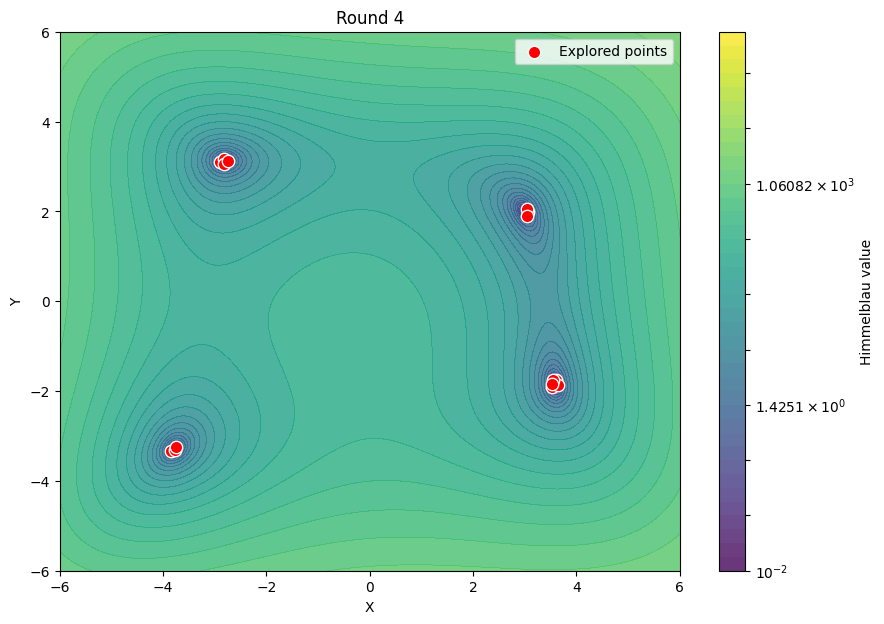

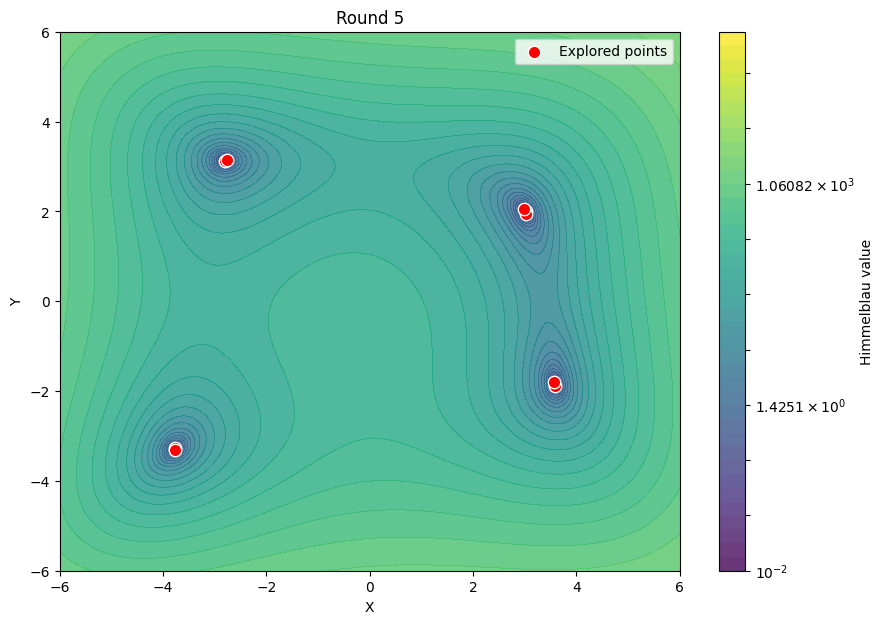

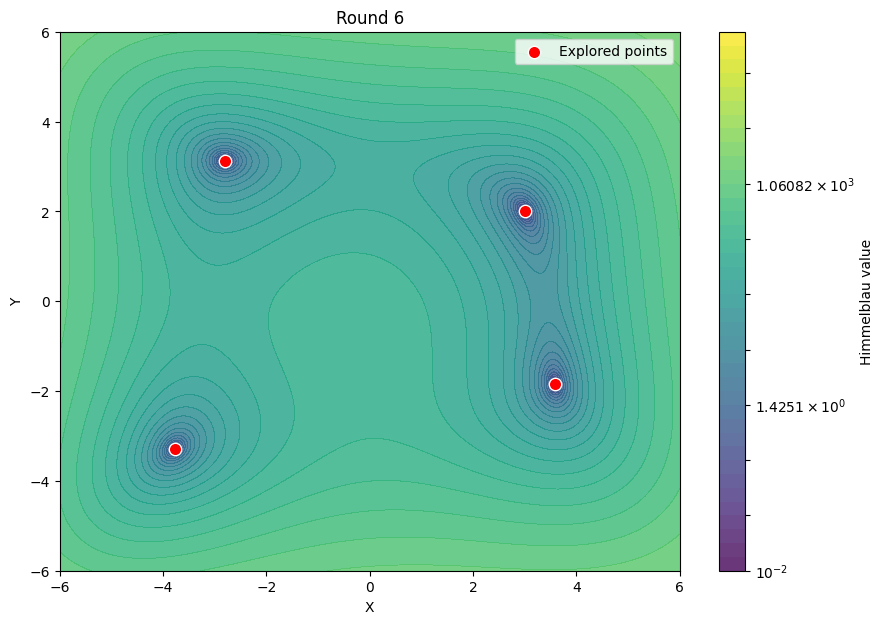

In [ ]:
def avaluacio(funcio, folder_path, save_plot: bool=False):

    csvs = [f for f in os.listdir(folder_path) if f.endswith('.csv') and f.startswith(f'{funcio.name}') and "RESULTADO" not in f and "plot" not in f]
    csvs = sorted(csvs, key=lambda f: int(f.split('_')[-1].replace('.csv', '').replace('R', '')))
    for file in csvs:
        full_path = os.path.join(folder_path, file)
        output_file = file.replace('.csv', '_RESULTADO.csv')
        plot_file   = file.replace('.csv', '_plot.jpg')
        round       = int(file.split('_')[-1].replace('.csv', '').replace('R', '')) # Extrae el número de round del nombre del archivo

        print("-" * 30)
        print(f"Procesando archivo: {file}")
        print(f"Guardando Output en {output_file}")
        print(f"Guardando Gráfico en {plot_file}")
        print(f"Round: {round}")
        print("-" * 30)

        val_x, val_y, df = lectura(full_path)

        # 4. Calcular el resultado y guardarlo en la nueva columna 4 (indice 3)
        df['real'] = funcio.evaluate(val_x, val_y)

        # 5. Guardar el archivo actualizado en el Escritorio
        df.to_csv(folder_path+output_file, index=False)

        print(df.head()) # Mostrar los primeros resultados para verificar
        plt = plot_round(val_x, val_y, funcio, str(round))

        if save_plot:
            plt.savefig(folder_path+plot_file, dpi=300, bbox_inches='tight')
            print(f"Gráfico guardado correctamente como :{plot_file}")

## MAE + DISTANCE VALUES

In [ ]:
def metriques(funcio, folder_path):

    csvs_results = [f for f in os.listdir(folder_path) if f.endswith('RESULTADO.csv') and f.startswith(f'{funcio.name}')]
    csvs_results = sorted(csvs_results, key=lambda f: int(f.split('_')[-2].replace('.csv', '').replace('R', '')))

    resum_csv = []
    for file in csvs_results:
        file_path = os.path.join(folder_path, file)

        val_x, val_y, df = lectura(file_path) ## llegim les dades
        #val_real = funcio.evaluate(val_x, val_y) ## calcul del valor REAl de la funcio per a cada punt

        # 3. DISTÀNCIES: Calculem la distància de cada punt al mínim global de la funció i guardem aquestes distàncies en noves columnes al DataFrame
        for i, (mx, my) in enumerate(funcio.minima, 1):
            df[f'M{i}'] = np.sqrt((val_x - mx)**2 + (val_y - my)**2)

        # 4. MAE: Calculem l'error punt a punt i fem la mitjana final
        if 'R1' in df.columns:
            df['Error_Puntual'] = np.abs(df['R1'] - df['real'])
            mae_final = df['Error_Puntual'].mean()
        else:
            mae_final = 0 # Per si és la R0 i no hi ha predicció encara

        # 5. RESULTATS
        # Extraiem el número de ronda del nom del fitxer per al print
        ronda_nom = file.split('_')[1] 

     # --- 2. EN EL DICCIONARI ES GUARDA SOLS UNA DISTÀNCIA AL MÍNIM GLOBAL ---
        fila_resum = {
            'ROUNDS': ronda_nom,
            'MAE': mae_final,
            'Distance': df['M1'].min() # La distància mínima al mínim global (3, 0.5) que has calculat a la columna M1
        }

        # Afegim la fila a la nostra llista
        resum_csv.append(fila_resum)

        # Mantenim els teus prints per veure-ho per pantalla
        print(f"Funcio: {funcio.name}. Ronda: {ronda_nom}. MAE: {mae_final:.4f}")

    # --- 3. CREAR EL CSV FINAL AMB TOTS ELS RESULTATS ---
    df_final = pd.DataFrame(resum_csv)

    # Opcional: Ordenar les rondes numèricament perquè el gràfic no surti desordenat
    #df_final['n'] = df_final['ROUNDS'].str.extract('(\d+)').astype(int)
    #df_final = df_final.sort_values('n').drop(columns=['n'])

    # Guardem el fitxer que llegirà el codi del gràfic
    ruta_sortida = os.path.join(folder_path, f"Summary_{funcio.name}.csv")
    df_final.to_csv(ruta_sortida, index=False)

    print("\n" + "="*40)
    print(f"Fitxer guardat correctament a:\n{ruta_sortida}")
    print("="*40)
    print(df_final.to_string(index=False))

Columnas detectadas: ['RUN', 'X', 'Y', 'real']
Funcio: Himmelblau. Ronda: R0. MAE: 0.0000
Columnas detectadas: ['Number', 'X', 'Y', 'R1', 'real']
Funcio: Himmelblau. Ronda: R1. MAE: 679.7522
Columnas detectadas: ['Number', 'X', 'Y', 'R1', 'real']
Funcio: Himmelblau. Ronda: R2. MAE: 0.0044
Columnas detectadas: ['Number', 'X', 'Y', 'R1', 'real']
Funcio: Himmelblau. Ronda: R3. MAE: 0.0045
Columnas detectadas: ['Number', 'X', 'Y', 'R1', 'real']
Funcio: Himmelblau. Ronda: R4. MAE: 1.3121
Columnas detectadas: ['Number', 'X', 'Y', 'R1', 'real']
Funcio: Himmelblau. Ronda: R5. MAE: 0.0006
Columnas detectadas: ['Number', 'X', 'Y', 'R1', 'real']
Funcio: Himmelblau. Ronda: R6. MAE: 0.0003

Fitxer guardat correctament a:
/Users/sergivela/Documents/Melina/TFM-Emma/TFM-MELINA/Himmelblau/Summary_Himmelblau.csv
ROUNDS        MAE  Distance
    R0   0.000000  2.424954
    R1 679.752182  2.891562
    R2   0.004409  0.650692
    R3   0.004504  0.270601
    R4   1.312094  0.061392
    R5   0.000573  0.01931

**PLOTS**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- CÀRREGA DE DADES ---
BASE_DIR = os.getcwd()
folder_path = BASE_DIR
input_consolidat = os.path.join(folder_path, "Summary_Table_Rosenbrock.csv")


def plots(funcio, folder_path):

    if os.path.exists(input_consolidat):
        df = pd.read_csv(input_consolidat)
        df['Num_Ronda'] = df['ROUNDS'].str.replace('R', '').astype(int)
        df = df.sort_values('Num_Ronda')

        # --- CONFIGURACIÓ ESTÈTICA ---
        plt.rcParams['font.family'] = 'sans-serif'
        color_sampling = '#219ebc' # Triem només un color per a la línia única
        color_fitting = '#6a1b9a'

        # =========================================================
        # --- PLOT 1: SAMPLING (Sols 1 distància per a Beale) ---
        # =========================================================
        fig, ax1 = plt.subplots(figsize=(10, 6))

        # MODIFICACIÓ AQUÍ: Només una columna i una etiqueta
        ax1.plot(df['Num_Ronda'], df['Distance'], 
                 marker='o', markersize=8, markerfacecolor='white', markeredgewidth=2,
                 linestyle='-', linewidth=3, color=color_sampling, 
                 label='Global Minimum (3, 0.5)', alpha=0.9)

        ax1.set_title('Space exploration (Sampling) - Rosenbrock', loc='left', fontsize=16, fontweight='bold', pad=20)
        ax1.set_xticks(df['Num_Ronda'])
        ax1.set_xlabel('Round', fontsize=12)
        ax1.set_ylabel('Distance to Minimum', fontsize=12)

        ax1.legend(frameon=False)
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        ax1.grid(axis='y', linestyle='--', alpha=0.3) # Opcional: una miqueta de graella horitzontal

        plt.tight_layout()
        plt.show()

        # =========================================================
        # --- PLOT 2: FITTING (MAE) ---
        # =========================================================
        fig, ax2 = plt.subplots(figsize=(10, 5))
        ax2.fill_between(df['Num_Ronda'], df['MAE'], color=color_fitting, alpha=0.1)
        ax2.plot(df['Num_Ronda'], df['MAE'], marker='s', markersize=7, color=color_fitting, linewidth=3)

        ax2.set_title('Model convergence (Fitting) - Rosenbrock', loc='left', fontsize=16, fontweight='bold', pad=20)
        ax2.set_xticks(df['Num_Ronda'])
        ax2.set_xlabel('Round', fontsize=12)
        ax2.set_ylabel('Mean Absolute Error (MAE)', fontsize=12)
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)

        # Anotació final
        final_mae = df['MAE'].iloc[-1]
        ax2.annotate(f'Final: {final_mae:.4f}', 
                     xy=(df['Num_Ronda'].iloc[-1], final_mae),
                     xytext=(-60, 20), textcoords='offset points',
                     arrowprops=dict(arrowstyle='->', color='#555555'))

        plt.tight_layout()
        plt.show()
    else:
        print(f"Error: No s'ha trobat {input_consolidat}.")

Error: No s'ha trobat c:\Users\emmar\Desktop\TFM_MuBiB_Emma-Reig-1\Rosenbrock\Summary_Table_Rosenbrock.csv.


In [ ]:
funcions = [Himmelblau(), Rosenbrock(), Beale(), Rastrigin()]

for funcio in funcions:
    BASE_DIR = os.getcwd()
    folder_path = BASE_DIR+f"/{funcio.name}/"

    avaluacio(funcio, folder_path)
    metriques(funcio, folder_path)
    plots(funcio, folder_path)
